In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import random

# Reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-02-21 15:30:45.967103: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771687846.145464      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771687846.198491      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771687846.593591      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771687846.593631      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771687846.593634      55 computation_placer.cc:177] computation placer alr

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [4]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

In [5]:
model = Sequential([

    Conv2D(32, 3, padding='same',
           activation='relu',
           kernel_initializer='he_normal',
           input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, 3, padding='same',
           activation='relu',
           kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, 3, padding='same',
           activation='relu',
           kernel_initializer='he_normal'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1771687915.097317      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771687915.103406      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

In [8]:
start_train = time.time()

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=50,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

train_time = time.time() - start_train
print("Training time (sec):", round(train_time,2))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1771687947.876412     129 service.cc:152] XLA service 0x7d046800b210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771687947.876463     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771687947.876470     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771687948.389975     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


  6/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.1464 - loss: 3.7403

I0000 00:00:1771687952.016838     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 39ms/step - accuracy: 0.3141 - loss: 1.9602 - val_accuracy: 0.4620 - val_loss: 1.5049 - learning_rate: 0.0010
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4665 - loss: 1.4695 - val_accuracy: 0.5584 - val_loss: 1.2463 - learning_rate: 0.0010
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.5379 - loss: 1.2942 - val_accuracy: 0.6319 - val_loss: 1.0729 - learning_rate: 0.0010
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.5807 - loss: 1.1942 - val_accuracy: 0.6189 - val_loss: 1.1510 - learning_rate: 0.0010
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.6116 - loss: 1.1160 - val_accuracy: 0.6033 - val_loss: 1.1665 - learning_rate: 0.0010
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.6360 - loss: 1.0493 - val_accuracy: 0.6539 - val_loss: 1.0208 - learning_rate: 0.0010
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.6573 - loss: 0.9990

In [9]:
start_inf = time.time()
_ = model.predict(x_test[:1000], verbose=0)
inf_time = (time.time() - start_inf) / 1000

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("Test Accuracy:", test_acc)
print("Parameters:", model.count_params())
print("Avg inference time per image (sec):", inf_time)

Test Accuracy: 0.8195000290870667
Parameters: 357706
Avg inference time per image (sec): 0.0012915513515472411


In [10]:
os.makedirs("saved_models", exist_ok=True)
model.save("saved_models/baseline_cnn_improved.h5")

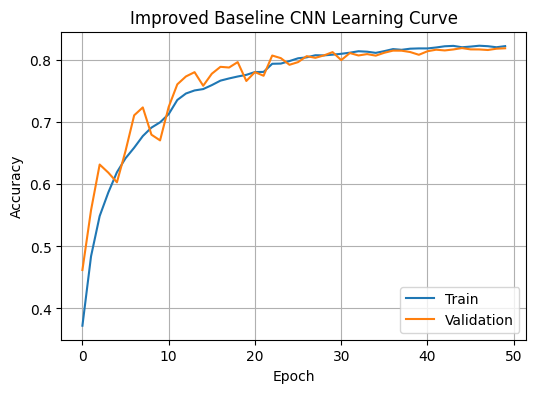

In [11]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved Baseline CNN Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

PHASE 2 — ANN → SNN CONVERSION (FROM SCRATCH)

In [13]:
!pip install snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 3.9 MB/s eta 0:00:00


In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import snntorch as snn
from snntorch import surrogate
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import snntorch as snn
from snntorch import surrogate
import numpy as np

In [30]:
model   # trained Keras model

<Sequential name=sequential, built=True>

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [33]:
print([name for name in globals() if "train" in name.lower()])

['x_train', 'y_train', 'start_train', 'train_time', 'x_train_tensor', 'y_train_tensor', 'train_dataset', 'train_loader', 'train_snn']


In [34]:
from torch.utils.data import TensorDataset, DataLoader

# Convert numpy arrays to torch tensors
X_train_torch = torch.tensor(x_train, dtype=torch.float32).permute(0,3,1,2)
y_train_torch = torch.tensor(y_train.squeeze(), dtype=torch.long)

X_test_torch = torch.tensor(x_test, dtype=torch.float32).permute(0,3,1,2)
y_test_torch = torch.tensor(y_test.squeeze(), dtype=torch.long)

train_dataset = TensorDataset(X_train_torch, y_train_torch)
test_dataset = TensorDataset(X_test_torch, y_test_torch)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [35]:
spike_grad = surrogate.fast_sigmoid()

class LiteSNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(32*32*3, 256)
        self.lif1 = snn.Leaky(beta=0.95, spike_grad=spike_grad)
        
        self.fc2 = nn.Linear(256, 10)
        self.lif2 = snn.Leaky(beta=0.95, spike_grad=spike_grad)

        self.T = 15

    def forward(self, x, record_spikes=False):
        x = x.view(x.size(0), -1)

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spike_counter = 0
        spk_out = 0

        for _ in range(self.T):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            if record_spikes:
                spike_counter += spk1.sum() + spk2.sum()

            spk_out += spk2

        if record_spikes:
            return spk_out / self.T, spike_counter.item()
        else:
            return spk_out / self.T

In [36]:
def distillation_loss(student_logits, teacher_logits, temp=3.0, alpha=0.7):

    soft_teacher = torch.softmax(teacher_logits / temp, dim=1)
    soft_student = torch.log_softmax(student_logits / temp, dim=1)

    kd_loss = nn.KLDivLoss(reduction="batchmean")(soft_student, soft_teacher)
    ce_loss = nn.CrossEntropyLoss()(student_logits, teacher_logits.argmax(1))

    return alpha * kd_loss + (1 - alpha) * ce_loss

In [38]:
teacher_out = model.predict(x_numpy, verbose=0)
teacher_out = torch.tensor(teacher_out, dtype=torch.float32).to(device)

In [45]:
snn_model = LiteSNN().to(device)
optimizer = optim.Adam(snn_model.parameters(), lr=1e-3)

epochs = 20

for epoch in range(epochs):

    snn_model.train()
    total_loss = 0

    for x, y in train_loader:

        x, y = x.to(device), y.to(device)

        # convert back to numpy for CNN teacher
        x_numpy = x.permute(0,2,3,1).cpu().numpy()

        teacher_out = model.predict(x_numpy, verbose=0)
        teacher_out = torch.tensor(teacher_out, dtype=torch.float32).to(device)

        student_out = snn_model(x)

        loss = distillation_loss(student_out, teacher_out)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")

Epoch 1 | Loss: 0.6633
Epoch 2 | Loss: 0.6369
Epoch 3 | Loss: 0.6299
Epoch 4 | Loss: 0.6266
Epoch 5 | Loss: 0.6241
Epoch 6 | Loss: 0.6251
Epoch 7 | Loss: 0.6275
Epoch 8 | Loss: 0.6245
Epoch 9 | Loss: 0.6224
Epoch 10 | Loss: 0.6210
Epoch 11 | Loss: 0.6219
Epoch 12 | Loss: 0.6180
Epoch 13 | Loss: 0.6194
Epoch 14 | Loss: 0.6219
Epoch 15 | Loss: 0.6171
Epoch 16 | Loss: 0.6178
Epoch 17 | Loss: 0.6179
Epoch 18 | Loss: 0.6172
Epoch 19 | Loss: 0.6192
Epoch 20 | Loss: 0.6205


In [47]:
def evaluate_snn(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

acc = evaluate_snn(snn_model, test_loader)
print("Final SNN Accuracy:", acc)

Final SNN Accuracy: 0.2672


In [48]:
def count_spikes(model, loader):
    model.eval()
    total_spikes = 0

    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            _, spikes = model(x, record_spikes=True)
            total_spikes += spikes

    return total_spikes

total_spikes = count_spikes(snn_model, test_loader)
avg_spikes = total_spikes / len(test_loader.dataset)

print("Total Spikes:", total_spikes)
print("Avg Spikes per Image:", avg_spikes)

Total Spikes: 16069513.0
Avg Spikes per Image: 1606.9513


In [49]:
cnn_params = model.count_params()

def count_torch_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

snn_params = count_torch_params(snn_model)

print("CNN Params:", cnn_params)
print("Lite SNN Params:", snn_params)

CNN Params: 357706
Lite SNN Params: 789258


In [54]:
import pandas as pd

results = {
    "Model": ["CNN", "LiteSNN"],
    "Accuracy": [test_acc, acc],
    "Parameters": [cnn_params, snn_params],
    "Avg Spikes per Image": ["—", avg_spikes]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Parameters,Avg Spikes per Image
0,CNN,0.8195,357706,—
1,LiteSNN,0.2672,789258,1606.9513


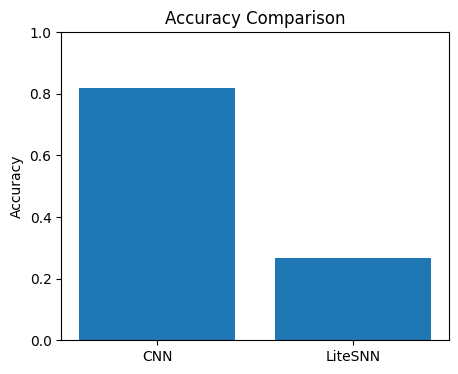

In [55]:
import matplotlib.pyplot as plt

models = ["CNN", "LiteSNN"]
accuracies = [test_acc, acc]

plt.figure(figsize=(5,4))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.ylim(0,1)
plt.show()

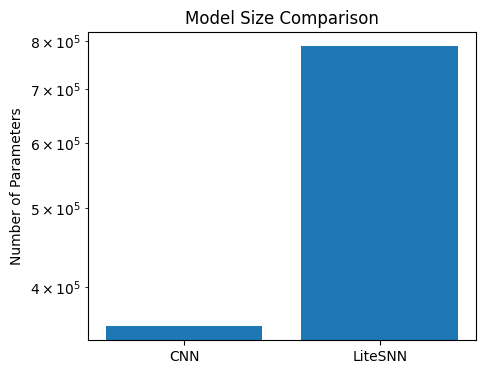

In [57]:
params = [cnn_params, snn_params]

plt.figure(figsize=(5,4))
plt.bar(models, params)
plt.ylabel("Number of Parameters")
plt.title("Model Size Comparison")
plt.yscale("log")
plt.show()

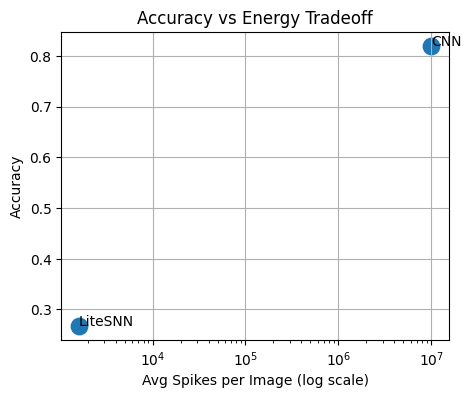

In [65]:
import matplotlib.pyplot as plt

models = ["CNN", "LiteSNN"]

# CNN has no spike cost → set very large value or skip it
spikes = [1e7, avg_spikes]     
accuracies = [test_acc, acc]

plt.figure(figsize=(5,4))

plt.scatter(spikes, accuracies, s=140)

for x, y, name in zip(spikes, accuracies, models):
    plt.text(x, y, name)

plt.xscale("log")
plt.xlabel("Avg Spikes per Image (log scale)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Energy Tradeoff")

plt.grid(True)
plt.show()